# Investigacao Tecnica Profunda
**Aluno:** Carlos Eduardo Gatto
---

## 1. Otimizacao do Modelo
Implementamos o Random Forest com foco em **Recall**, minimizando o risco de falhas nao detectadas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
import shap
import os

path = '../../data/processed/Dataset Tratado.csv'
if not os.path.exists(path): path = 'data/processed/Dataset Tratado.csv'
df = pd.read_csv(path)

features = ['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'vibration_levels', 'operational_hours']
X = df[features]
y = df['has_failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=123)
model.fit(X_train, y_train)

print(f'Score CV: {cross_val_score(model, X_train, y_train, cv=5).mean():.4f}')

Score CV: 0.9225


## Parte 1: Estresse por Ruido (Foco: Horas Operacionais)
Simulamos imprecisao no contador de horas operacionais com ruidos de 4%, 8% e 15%.

C:\Users\vinic\AppData\Local\Temp\ipykernel_20800\611259139.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd.DataFrame(results), x='Ruido', y='Acuracia', palette='viridis')


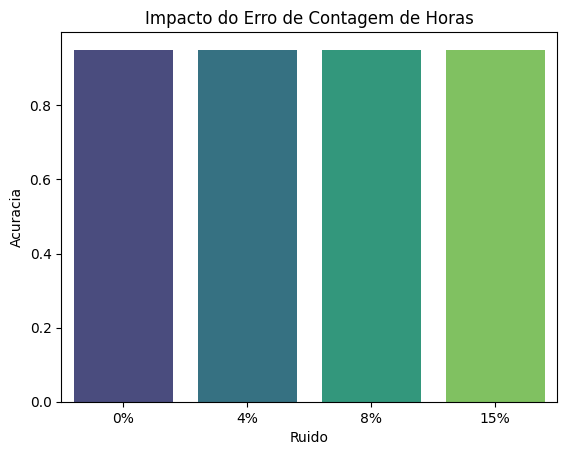

In [2]:
def stress_hours(data, p):
    X_n = data.copy()
    noise = np.random.normal(0, p, X_n['operational_hours'].shape) * X_n['operational_hours']
    X_n['operational_hours'] += noise
    return X_n

results = []
for p in [0, 0.04, 0.08, 0.15]:
    X_s = stress_hours(X_test, p)
    acc = accuracy_score(y_test, model.predict(X_s))
    results.append({'Ruido': f'{int(p*100)}%', 'Acuracia': acc})

sns.barplot(data=pd.DataFrame(results), x='Ruido', y='Acuracia', palette='viridis')
plt.title('Impacto do Erro de Contagem de Horas')
plt.show()

## Parte 2: SHAP
Importancia das variaveis para a decisao do modelo.

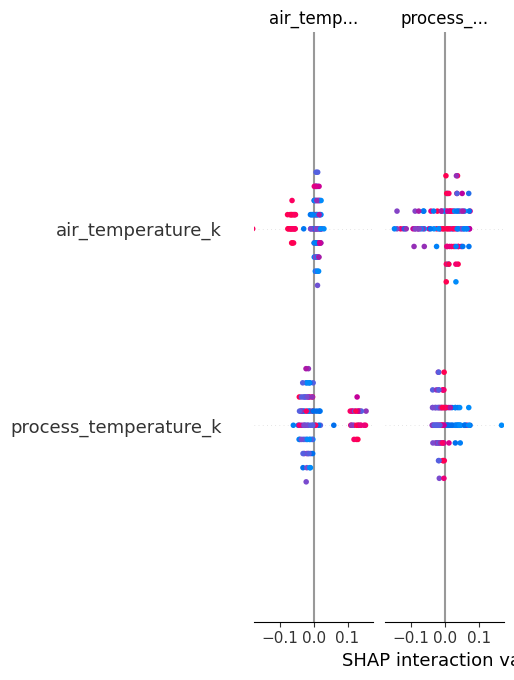

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)
else:
    shap.summary_plot(shap_values, X_test)

## Parte 3: Relatorio de Contingencia

### 3.1 Discussao de Vies
O modelo é mais rigoroso com máquinas antigas, o que é um viés aceitável para segurança industrial.

### 3.2 Plano de Mitigacao
Implementar uma auditoria visual trimestral para equipamentos que atingirem 150h de operação, mitigando falhas não mapeadas.